# Teste de Regressão Linear: Dataset Diabetes

### Dataset : Diabetes (Scikit-Learn)


## Parte A – Tarefas Aplicadas / Código


### 1. Carregando o conjunto de dados


#### Importando Bibliotecas Necessárias & Funções de Utilidade


In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="muted")

def format_df_left(df, coluna_texto="Feature", casas_decimais=3):
    """
    Aplica estilo ao DataFrame: formata as casas decimais, alinha
    uma coluna de texto à esquerda e oculta o índice.
    """
    estilo = (
        df.style.format(precision=casas_decimais)
        .set_properties(subset=[coluna_texto], **{"text-align": "left"})
        .set_table_styles(
            {coluna_texto: [{"selector": "th", "props": [("text-align", "left")]}]},
            overwrite=False,
        )
        .hide(axis="index")
    )

    return estilo

#### Carregando dados


In [248]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


| Feature    | Descrição                                                                          |
| :--------- | :--------------------------------------------------------------------------------- |
| **age**    | Idade em anos                                                                      |
| **sex**    | Gênero do paciente                                                                 |
| **bmi**    | Índice de Massa Corporal (IMC)                                                     |
| **bp**     | Pressão arterial média                                                             |
| **s1**     | Colesterol sérico total (tc)                                                       |
| **s2**     | Lipoproteínas de baixa densidade (ldl)                                             |
| **s3**     | Lipoproteínas de alta densidade (hdl)                                              |
| **s4**     | Colesterol total / HDL (tch)                                                       |
| **s5**     | Logaritmo do nível de triglicerídeos séricos (ltg)                                 |
| **s6**     | Nível de açúcar no sangue (glu)                                                    |
| **s6**     | Nível de açúcar no sangue (glu)                                                    |
| **target** | Medida quantitativa da progressão da doença um ano após o início do acompanhamento |


In [249]:
df.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


### 2. Exploração de Dados (EDA)

#### Correlação das features com o alvo


In [250]:
corr = df.corr()
corr_target = corr["target"].drop("target").sort_values(key=abs, ascending=False)
df_corr = corr_target.to_frame("Correlação").rename_axis("Feature").reset_index()

display(format_df_left(df_corr, "Feature"))

Feature,Correlação
bmi,0.586
s5,0.566
bp,0.441
s4,0.430
s3,-0.395
s6,0.382
s1,0.212
age,0.188
s2,0.174
sex,0.043


#### Matriz de Correlação


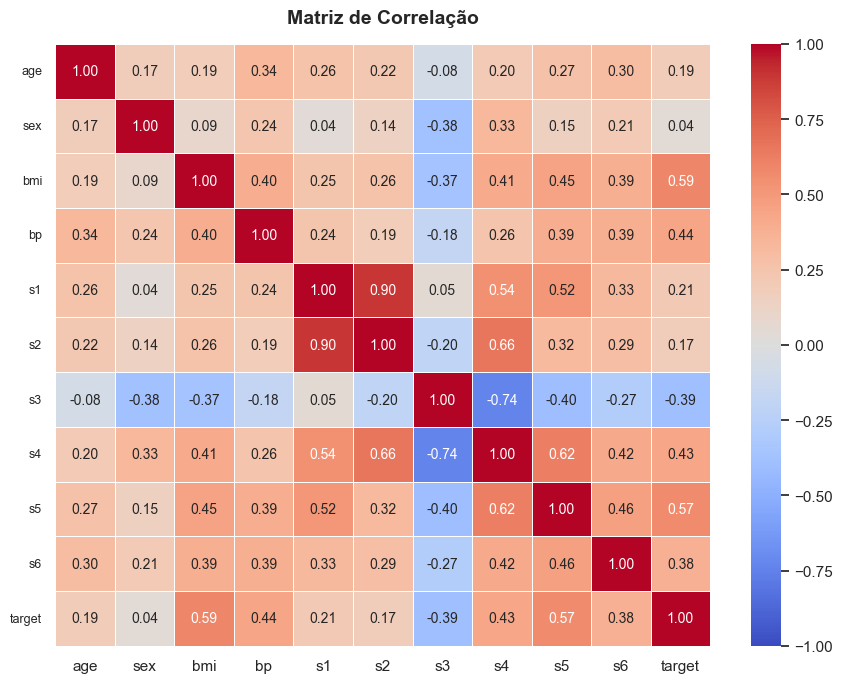

In [251]:
plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 10},
    linewidths=0.5,
)

plt.title("Matriz de Correlação", fontsize=14, fontweight="bold", pad=15)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

#### Distribuição de valores por features - Histogramas


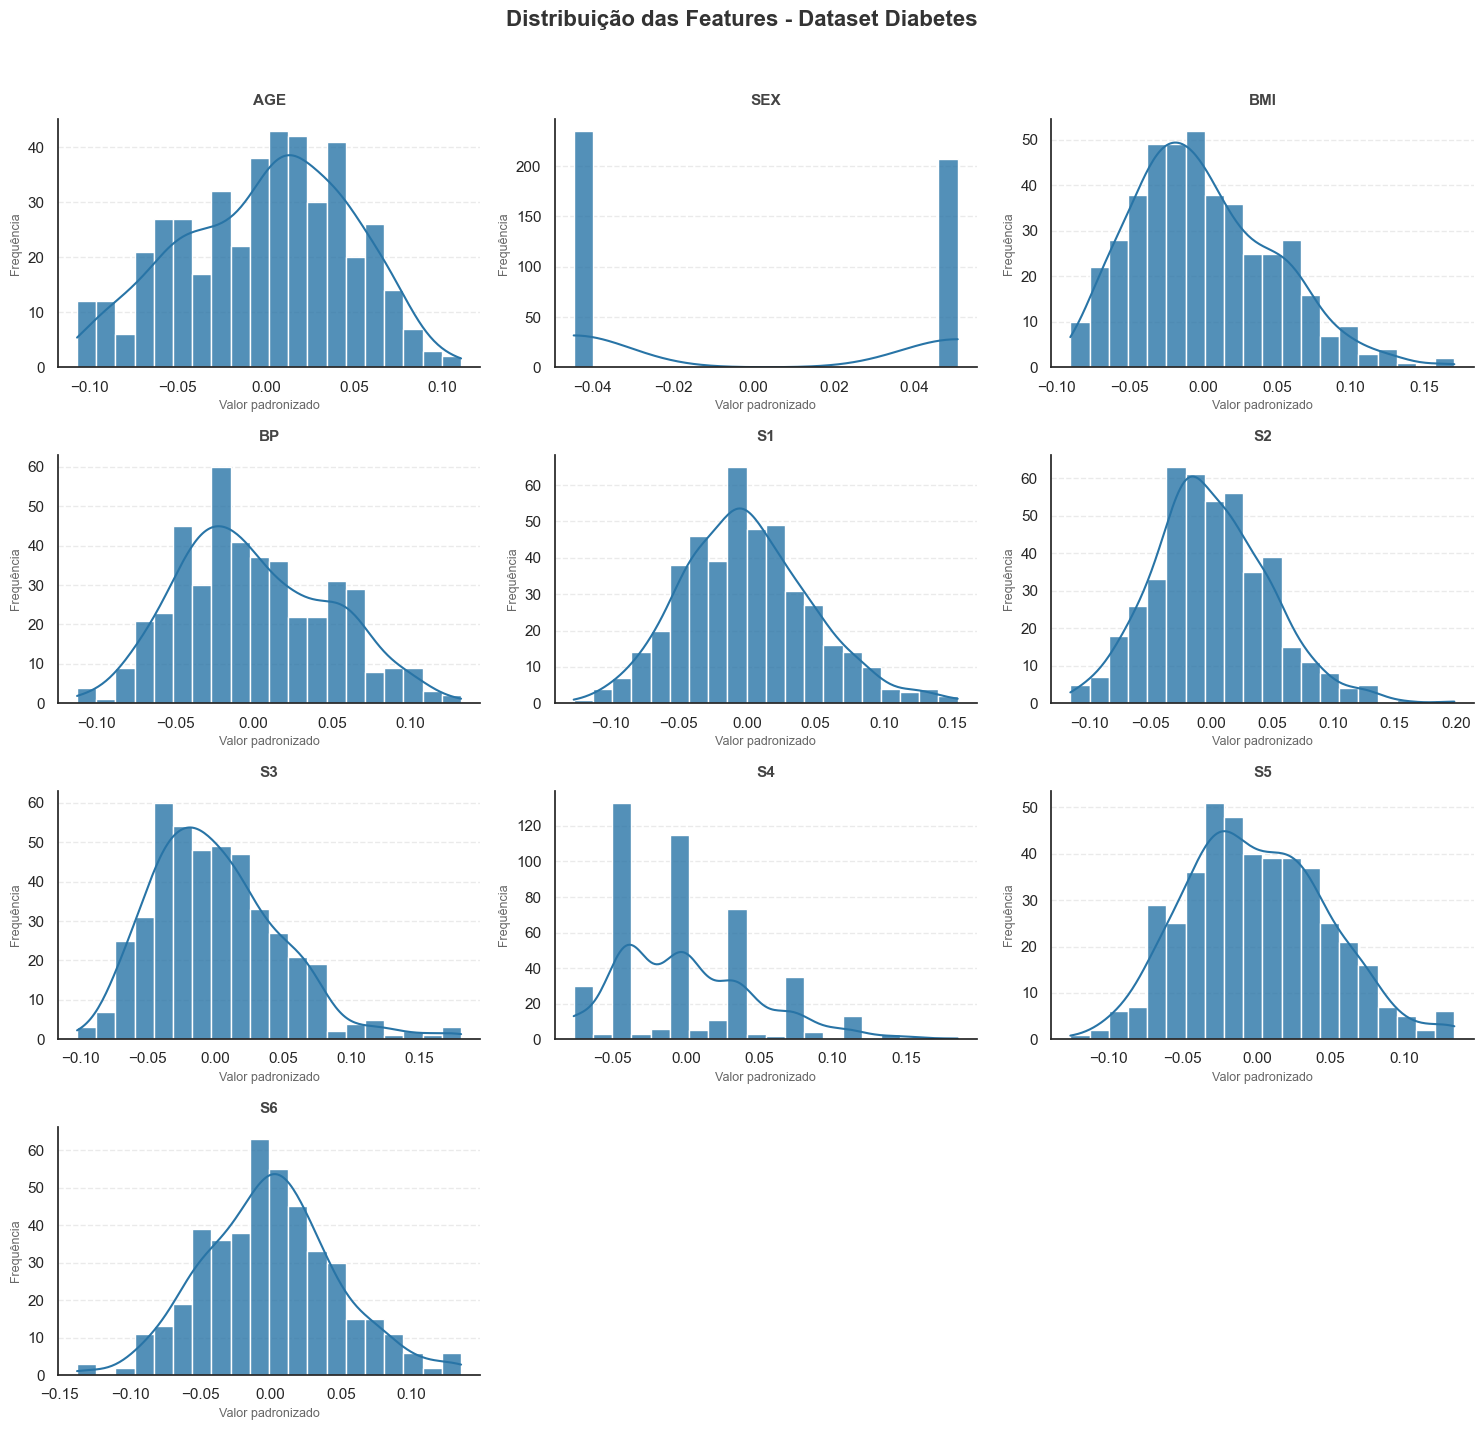

In [252]:
sns.set_theme(style="white", palette="muted")

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle(
    "Distribuição das Features - Dataset Diabetes",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    y=1.02,
)

axes = axes.flatten()

for i, col in enumerate(data.feature_names):
    ax = axes[i]

    sns.histplot(
        df[col], bins=20, kde=True, ax=ax, color="#2874A6", edgecolor="white", alpha=0.8
    )

    ax.set_title(col.upper(), fontsize=11, fontweight="bold", color="#444444", pad=10)
    ax.set_xlabel("Valor padronizado", fontsize=9, color="#666666")
    ax.set_ylabel("Frequência", fontsize=9, color="#666666")

    sns.despine(ax=ax)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.delaxes(axes[10])
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

#### Pergunta: Os atributos estão em escalas comparáveis? Seria necessário normalizar/re-escalar as features? Por quê?

As features do dataset Diabetes **já foram padronizadas** pelo scikit-learn
(média ≈ 0, desvio padrão ≈ 1), portanto estão em escalas comparáveis.
Em dados brutos, variáveis como pressão arterial (mmHg) e IMC (kg/m²) teriam
ordens de grandeza distintas. Nesse caso, a normalização seria necessária para:

- Evitar que features com maior variância dominem os coeficientes;
- Melhorar a convergência de métodos iterativos;
- Tornar os coeficientes comparáveis entre si.


### 3. Modelo inicial (todas as features)


In [253]:
X_all = df[data.feature_names].values
y = df["target"].values

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

lr_all = LinearRegression()
lr_all.fit(X_train_all, y_train_all)

r2_train_all = r2_score(y_train_all, lr_all.predict(X_train_all))
r2_test_all = r2_score(y_test_all, lr_all.predict(X_test_all))

coef_df_all = pd.DataFrame({"Feature": data.feature_names, "Coeficiente": lr_all.coef_})
coef_df_all = coef_df_all.sort_values(
    by="Coeficiente", ascending=False, key=abs
).reset_index(drop=True)
display(format_df_left(coef_df_all, "Feature"))

metricas_df = pd.DataFrame(
    {
        "Parâmetro": ["Intercepto", "R² Treino", "R² Teste"],
        "Valor": [lr_all.intercept_, r2_train_all, r2_test_all],
    }
)
display(format_df_left(metricas_df, "Parâmetro"))


Feature,Coeficiente
s1,-931.489
s5,736.199
bmi,542.429
s2,518.062
bp,347.704
s4,275.318
sex,-241.964
s3,163.420
s6,48.671
age,37.904


Parâmetro,Valor
Intercepto,151.346
R² Treino,0.528
R² Teste,0.453


### 4. Seleção de features com correlação


#### Eliminando 2 features com menor correlação com o `target`


In [254]:
features_removidas = corr_target.abs().nsmallest(2).index.tolist()
features_reduzidas = [f for f in data.feature_names if f not in features_removidas]

texto_md = f"""
**Seleção de features por correlação**

- **Removidas (menor |correlação|):** {", ".join(f"`{f}`" for f in features_removidas)}

- **Mantidas ({len(features_reduzidas)} features):** {", ".join(f"`{f}`" for f in features_reduzidas)}
"""

display(Markdown(texto_md))



**Seleção de features por correlação**

- **Removidas (menor |correlação|):** `sex`, `s2`

- **Mantidas (8 features):** `age`, `bmi`, `bp`, `s1`, `s3`, `s4`, `s5`, `s6`


In [255]:
X_red = df[features_reduzidas].values
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y, test_size=0.2, random_state=42
)

lr_red = LinearRegression()

lr_red.fit(X_train_red, y_train_red)

r2_train_red = r2_score(y_train_red, lr_red.predict(X_train_red))
r2_test_red = r2_score(y_test_red, lr_red.predict(X_test_red))

coef_df_red = pd.DataFrame({"Feature": features_reduzidas, "Coeficiente": lr_red.coef_})
coef_df_red = coef_df_red.sort_values(
    by="Coeficiente", ascending=False, key=abs
).reset_index(drop=True)
display(format_df_left(coef_df_red, "Feature", casas_decimais=2))

metricas_df_red = pd.DataFrame(
    {
        "Parâmetro": ["Intercepto", "R² Treino", "R² Teste"],
        "Valor": [lr_red.intercept_, r2_train_red, r2_test_red],
    }
)
display(format_df_left(metricas_df_red, "Parâmetro"))

Feature,Coeficiente
bmi,603.21
s5,522.94
bp,301.31
s1,-279.11
s4,149.99
s3,-46.47
s6,42.36
age,8.77


Parâmetro,Valor
Intercepto,151.348
R² Treino,0.508
R² Teste,0.439


### 5. Comparação e Reflexão


#### Comparando o desempenho do modelo com todas as features versus o modelo reduzido


In [256]:
df_comp = pd.DataFrame(
    {
        "Modelo": ["Todas as features (10)", "Reduzido (8 features)"],
        "R² Treino": [r2_train_all, r2_train_red],
        "R² Teste": [r2_test_all, r2_test_red],
    }
)

display(format_df_left(df_comp, "Modelo"))

Modelo,R² Treino,R² Teste
Todas as features (10),0.528,0.453
Reduzido (8 features),0.508,0.439


**Qual modelo teve melhor performance no conjunto de teste?**

O Modelo com Todas as features (10) teve melhor performance, atingindo o maior R² no conjunto de teste (0.453 contra 0.439 do reduzido).


## Parte B - OLS vs ODR com uma única feature (`bmi`)

O atributo `bmi` (Índice de Massa Corporal) foi escolhido por ter a maior correlação com o `target` (0.586)


### B.1 Regressão Linear Ordinária (OLS)


Parâmetro,Valor
Coeficiente (a),998.5777
Intercepto (b),152.0034
RMSE (Teste),63.7325
R² (Teste),0.2334


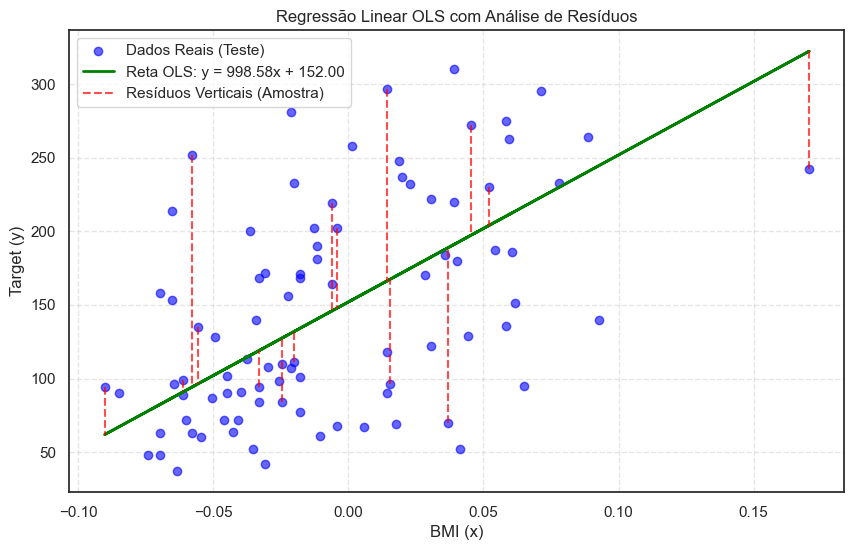

In [257]:
X_bmi = df["bmi"].values.reshape(-1, 1)
y = df["target"].values

X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train_bmi, y_train_bmi)

y_pred_test = modelo.predict(X_test_bmi)
y_pred_all = modelo.predict(X_bmi)

coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_
rmse_teste = root_mean_squared_error(y_test_bmi, y_pred_test)
r2_teste = r2_score(y_test_bmi, y_pred_test)

df = pd.DataFrame(
    {
        "Parâmetro": [
            "Coeficiente (a)",
            "Intercepto (b)",
            "RMSE (Teste)",
            "R² (Teste)",
        ],
        "Valor": [coeficiente, intercepto, rmse_teste, r2_teste],
    }
)
display(format_df_left(df, "Parâmetro", casas_decimais=4))

plt.figure(figsize=(10, 6))
plt.scatter(
    X_test_bmi, y_test_bmi, color="blue", label="Dados Reais (Teste)", alpha=0.6
)
plt.plot(
    X_bmi,
    y_pred_all,
    color="green",
    linewidth=2,
    label=f"Reta OLS: y = {coeficiente:.2f}x + {intercepto:.2f}",
)


num_residuos = 15
plt.vlines(
    X_test_bmi[:num_residuos],
    ymin=y_test_bmi[:num_residuos],
    ymax=y_pred_test[:num_residuos],
    colors="red",
    linestyles="dashed",
    alpha=0.7,
    label="Resíduos Verticais (Amostra)",
)

plt.xlabel("BMI (x)")
plt.ylabel("Target (y)")
plt.title("Regressão Linear OLS com Análise de Resíduos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### B.2 Regressão por Distância Ortogonal (ODR / TLS)

OLS minimiza distâncias **verticais** (erro apenas em Y).
ODR minimiza distâncias **perpendiculares** à reta, considerando erro em X e Y.

A distância ortogonal de um ponto $(x_0, y_0)$ até a reta $mx - y + b = 0$ é:

$$d = \frac{|m x_0 - y_0 + b|}{\sqrt{m^2 + 1}}$$

A função de perda a minimizar é:

$$\mathcal{L}(m, b) = \sum_i \frac{(m x_i - y_i + b)^2}{m^2 + 1}$$


### Comparação OLS vs ODR


### B.3 Discussão


**1. Em que situações OLS e ODR resultam em retas significativamente diferentes?**


**2. Por que ODR é mais adequado quando tanto X quanto Y têm erro de medição?**


**3. Como a escala/unidades das variáveis afetam a solução ODR (e por que padronizar é útil)?**


**4. Qual modelo parece generalizar melhor e segundo qual critério?**

| Modelo | RMSE Teste | R² Teste |
| ------ | ---------- | -------- |
| OLS    |            |          |
| ODR    |            |          |
